In [7]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# -----------------------------
# configuración general
# -----------------------------
CRS_PROJ = "EPSG:32719"
UMBRAL_CAMINATA_M = 1200
WALK_SPEED_M_MIN = 75
K_DESTINOS = 5
SEED = 42

np.random.seed(SEED)

In [8]:
# -----------------------------
# inputs principales
# -----------------------------
FP_MANZ = Path("../data/processed/censo/manzanas_penalolen_sim.parquet")
FP_WALK = Path("../data/processed/eod/tabla_walk_prob.csv")
FP_PURP = Path("../data/processed/eod/tabla_purpose_prob.csv")
FP_TIME = Path("../data/processed/eod/tabla_tiempos_caminata.csv")

FP_RED = Path("../data/raw/red_peatonal_penalolen.graphml")
FP_SALUD = Path("../data/raw/establecimientos_salud_penalolen.gpkg")
FP_COMERCIO = Path("../data/raw/comercio_penalolen.gpkg")
FP_VERDES = Path("../data/processed/destinations/verdes_points.gpkg")

In [9]:
print("Cargando red peatonal...")
G = ox.load_graphml(FP_RED)
G = ox.project_graph(G, to_crs=CRS_PROJ)

print("Cargando manzanas y tablas...")
manz = gpd.read_parquet(FP_MANZ).to_crs(CRS_PROJ)
tabla_walk = pd.read_csv(FP_WALK)
tabla_purp = pd.read_csv(FP_PURP)
tabla_time = pd.read_csv(FP_TIME)

print("Cargando destinos...")
salud = gpd.read_file(FP_SALUD).to_crs(CRS_PROJ)
comercio = gpd.read_file(FP_COMERCIO).to_crs(CRS_PROJ)
verdes = gpd.read_file(FP_VERDES).to_crs(CRS_PROJ)

print("manz:", manz.shape)
print("salud:", salud.shape)
print("comercio:", comercio.shape)
print("verdes:", verdes.shape)

Cargando red peatonal...
Cargando manzanas y tablas...
Cargando destinos...
manz: (1629, 14)
salud: (28, 41)
comercio: (173, 37)
verdes: (525, 3)


In [50]:
tabla_walk

,vuln_group,n_expand_total,n_expand_walk,p_walk_pure
0,baja,5435.166627,1819.096319,0.334690
1,media,5043.790750,2061.902945,0.408800
2,alta,5350.015259,2599.728057,0.485929


In [51]:
tabla_purp

,vuln_group,purpose_group,n_expand,prob
0,baja,compras_tramites,633.793235,0.768157
1,baja,salud,29.224046,0.035420
2,baja,social_recreacion,162.066159,0.196424
3,media,compras_tramites,729.453542,0.782280
4,media,salud,43.577654,0.046734
5,media,social_recreacion,159.440175,0.170987
6,alta,compras_tramites,982.893311,0.788757
7,alta,salud,75.089460,0.060258
8,alta,social_recreacion,188.147389,0.150985


In [52]:
tabla_time

,vuln_group,purpose_group,n,mean_time,median_time,p25,p75
0,baja,compras_tramites,429,11.624709,10.0,5.0,15.0
1,baja,salud,22,18.045455,15.0,10.0,25.0
2,baja,social_recreacion,113,14.761062,10.0,5.0,20.0
3,media,compras_tramites,494,12.773279,10.0,5.0,15.0
4,media,salud,31,20.193548,15.0,12.5,27.5
5,media,social_recreacion,111,14.603604,10.0,6.5,20.0
6,alta,compras_tramites,665,12.634586,10.0,5.0,15.0
7,alta,salud,55,18.709091,15.0,10.0,25.0
8,alta,social_recreacion,129,20.596899,15.0,10.0,20.0


In [10]:
manz["n_agents"] = np.where(
    manz["n_edad_60_mas"] > 0,
    np.maximum(1, np.round(manz["n_edad_60_mas"] / 10).astype(int)),
    0
)

print(manz[["n_edad_60_mas", "n_agents"]].describe())
print("Total agentes a simular:", manz["n_agents"].sum())

rows = []

for _, row in manz.iterrows():
    n = int(row["n_agents"])
    if n <= 0:
        continue

    for _ in range(n):
        rows.append({
            "MANZENT": row["MANZENT"],
            "COD_MANZANA": row["COD_MANZANA"],
            "vuln_group": row["vuln_group"],
            "indice_vulnerabilidad": row["indice_vulnerabilidad"],
            "ndvi_mean": row["ndvi_mean"],
            "ndvi_norm": row["ndvi_norm"],
            "x_rep": row["x_rep"],
            "y_rep": row["y_rep"]
        })

agents = pd.DataFrame(rows)
agents["agent_id"] = range(1, len(agents) + 1)

print("Dimensión agentes:", agents.shape)
agents.head()

       n_edad_60_mas     n_agents
count    1629.000000  1629.000000
mean       27.457336     2.796194
std        29.195460     2.879686
min         0.000000     0.000000
25%        13.000000     1.000000
50%        21.000000     2.000000
75%        31.000000     3.000000
max       345.000000    34.000000
Total agentes a simular: 4555
Dimensión agentes: (4555, 9)


,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,x_rep,y_rep,agent_id
0,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,1
1,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,2
2,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,3
3,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,4
4,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,5


In [47]:
walk_prob_map = dict(zip(tabla_walk["vuln_group"], tabla_walk["p_walk_pure"]))
print(walk_prob_map)

agents["p_walk_pure"] = agents["vuln_group"].map(walk_prob_map)
agents["will_walk"] = np.random.rand(len(agents)) < agents["p_walk_pure"]

print(agents["will_walk"].value_counts(normalize=True))

{'baja': 0.3346900736777181, 'media': 0.4088002549986125, 'alta': 0.4859290920751571}
will_walk
False    0.591218
True     0.408782
Name: proportion, dtype: float64


In [48]:
purpose_probs = {}

for vg in tabla_purp["vuln_group"].unique():
    sub = tabla_purp[tabla_purp["vuln_group"] == vg].copy()

    purposes = sub["purpose_group"].tolist()
    probs = sub["prob"].to_numpy(dtype=float)

    # ajuste leve opcional hacia salud
    if "salud" in purposes:
        probs[purposes.index("salud")] *= 2.0

    probs = probs / probs.sum()

    purpose_probs[vg] = {
        "purposes": purposes,
        "probs": probs.tolist()
    }

print(purpose_probs)

{'baja': {'purposes': ['compras_tramites', 'salud', 'social_recreacion'], 'probs': [0.7418795283045415, 0.06841575621138918, 0.18970471548406928]}, 'media': {'purposes': ['compras_tramites', 'salud', 'social_recreacion'], 'probs': [0.7473533850069074, 0.08929398516545699, 0.1633526298276357]}, 'alta': {'purposes': ['compras_tramites', 'salud', 'social_recreacion'], 'probs': [0.7439287884970552, 0.11366688572935092, 0.14240432577359388]}}


In [13]:
def sample_purpose(vg):
    d = purpose_probs[vg]
    return np.random.choice(d["purposes"], p=d["probs"])

In [49]:
agents["purpose_group_eod"] = None

mask_walk = agents["will_walk"]
agents.loc[mask_walk, "purpose_group_eod"] = (
    agents.loc[mask_walk, "vuln_group"].apply(sample_purpose)
)

print("Distribución propósito EOD:")
print(agents["purpose_group_eod"].value_counts(dropna=False, normalize=True))


Distribución propósito EOD:
purpose_group_eod
None                 0.591218
compras_tramites     0.299232
social_recreacion    0.070033
salud                0.039517
Name: proportion, dtype: float64


In [53]:
purpose_map = {
    "salud": "salud",
    "compras_tramites": "comercio",
    "social_recreacion": "areas_verdes"
}

agents["purpose_group_model"] = agents["purpose_group_eod"].map(purpose_map)

print("\nCruce EOD -> modelo:")
print(
    agents[["purpose_group_eod", "purpose_group_model"]]
    .drop_duplicates()
    .sort_values(["purpose_group_eod", "purpose_group_model"])
)

print("\nDistribución propósito modelo:")
print(agents["purpose_group_model"].value_counts(dropna=False, normalize=True))



Cruce EOD -> modelo:
    purpose_group_eod purpose_group_model
4    compras_tramites            comercio
38              salud               salud
2   social_recreacion        areas_verdes
0                None                 NaN

Distribución propósito modelo:
purpose_group_model
NaN             0.591218
comercio        0.299232
areas_verdes    0.070033
salud           0.039517
Name: proportion, dtype: float64


In [54]:
def standardize_destinations(gdf, purpose_name, id_prefix):
    out = gdf.copy()

    # por seguridad, si alguna capa no fuese punto
    if not out.geom_type.eq("Point").all():
        out["geometry"] = out.representative_point()

    out = out.reset_index(drop=True)
    out["dest_id"] = [f"{id_prefix}_{i}" for i in range(len(out))]
    out["purpose_group_model"] = purpose_name

    return out[["dest_id", "purpose_group_model", "geometry"]].copy()


In [55]:
dest_salud = standardize_destinations(salud, "salud", "salud")
dest_comercio = standardize_destinations(comercio, "comercio", "com")
dest_verdes = standardize_destinations(verdes, "areas_verdes", "verde")

destinos = pd.concat(
    [dest_salud, dest_comercio, dest_verdes],
    ignore_index=True
)

destinos = gpd.GeoDataFrame(destinos, geometry="geometry", crs=CRS_PROJ)

print("\nDestinos por propósito modelo:")
print(destinos["purpose_group_model"].value_counts())



Destinos por propósito modelo:
purpose_group_model
areas_verdes    525
comercio        173
salud            28
Name: count, dtype: int64


In [56]:
# --------------------------------------------------
# 6. Nodo de red para cada destino
# --------------------------------------------------

print("Asignando nodo de red a cada destino...")

destinos["dest_node"] = destinos.geometry.apply(
    lambda p: ox.distance.nearest_nodes(G, p.x, p.y)
)

print(destinos.head())

Asignando nodo de red a cada destino...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


   dest_id purpose_group_model                        geometry    dest_node
0  salud_0               salud  POINT (353434.200 6291266.143)  12081624095
1  salud_1               salud  POINT (353792.507 6291753.605)   4779454996
2  salud_2               salud  POINT (353291.018 6292017.275)  11393273754
3  salud_3               salud  POINT (353306.732 6292059.327)  11393273754
4  salud_4               salud  POINT (353577.132 6293478.774)   6943113240


In [57]:
# -----------------------------------
# convertir agents a GeoDataFrame
# -----------------------------------

agents["geometry"] = gpd.points_from_xy(
    agents["x_rep"],
    agents["y_rep"],
    crs=CRS_PROJ
)

agents = gpd.GeoDataFrame(
    agents,
    geometry="geometry",
    crs=CRS_PROJ
)

print("Agents ahora es GeoDataFrame:", type(agents))

print("Asignando nodo origen a cada agente...")

agents["origin_node"] = agents.geometry.apply(
    lambda p: ox.distance.nearest_nodes(G, p.x, p.y)
)

agents[["agent_id", "origin_node"]].head()

Agents ahora es GeoDataFrame: <class 'geopandas.geodataframe.GeoDataFrame'>
Asignando nodo origen a cada agente...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


,agent_id,origin_node
0,1,11071992926
1,2,11071992926
2,3,11071992926
3,4,11071992926
4,5,11071992926


In [67]:
def assign_destination(agent_geom, purpose, destinos_gdf, k=5):
    cand = destinos_gdf[destinos_gdf["purpose_group_model"] == purpose].copy()

    if cand.empty:
        return pd.Series({
            "dest_id": None,
            "dest_node": None
        })

    cand["euclid_dist"] = cand.geometry.distance(agent_geom)
    cand = cand.sort_values("euclid_dist").head(k).copy()

    cand["w"] = 1 / (cand["euclid_dist"] + 1)
    probs = cand["w"] / cand["w"].sum()

    chosen_idx = np.random.choice(cand.index, p=probs.values)
    chosen = cand.loc[chosen_idx]

    return pd.Series({
        "dest_id": chosen["dest_id"],
        "dest_node": chosen["dest_node"]
    })

In [69]:
walkers = agents[
    (agents["will_walk"] == True) &
    (agents["purpose_group_model"].notna())
].copy()

walkers[["dest_id", "dest_node"]] = walkers.apply(
    lambda row: assign_destination(
        agent_geom=row["geometry"],
        purpose=row["purpose_group_model"],
        destinos_gdf=destinos,
        k=K_DESTINOS
    ),
    axis=1
)

print("Walkers:", walkers.shape)
walkers[["agent_id", "purpose_group", "origin_node", "dest_node"]].head()

Walkers: (1862, 18)


,agent_id,purpose_group,origin_node,dest_node
2,3,None,11071992926,11989268253
3,4,None,11071992926,1859640228
4,5,compras_tramites,11071992926,8551738614
5,6,salud,4514399530,6013907749
7,8,None,4514399530,1710798668


In [71]:
def vulnerability_factor(vg):
    if vg == "alta":
        return 1.25
    elif vg == "media":
        return 1.10
    return 1.0

In [72]:
def classify_risk(heat_load):
    if heat_load >= 1200:
        return "alto"
    elif heat_load >= 700:
        return "medio"
    return "bajo"

In [73]:
def route_to_linestring(route, graph):
    coords = [(graph.nodes[n]["x"], graph.nodes[n]["y"]) for n in route]
    return LineString(coords)

In [74]:
def compute_route_ndvi(route_geom, manz):
    if route_geom is None:
        return np.nan

    if route_geom.geom_type == "Point":
        inter = manz[manz.contains(route_geom)].copy()

        if inter.empty:
            inter = manz[manz.intersects(route_geom)].copy()

        if inter.empty:
            return np.nan

        return inter["ndvi_mean"].mean()

    inter = manz[manz.intersects(route_geom)].copy()

    if inter.empty:
        return np.nan

    inter["geom_int"] = inter.geometry.intersection(route_geom)
    inter["len_int"] = inter["geom_int"].length

    total_len = inter["len_int"].sum()

    if total_len == 0:
        return np.nan

    ndvi_route = (inter["len_int"] * inter["ndvi_mean"]).sum() / total_len
    return ndvi_route

In [75]:
def simulate_trip(agent_row, graph, manz, walk_speed_m_min=75):
    origin = agent_row["origin_node"]
    dest = agent_row["dest_node"]

    if pd.isna(dest):
        return {
            "route": None,
            "route_length_m": np.nan,
            "travel_time_min_model": np.nan,
            "heat_load": np.nan,
            "risk_level": "error",
            "ndvi_route": np.nan
        }

    try:
        route = nx.shortest_path(graph, origin, dest, weight="length")
    except Exception:
        return {
            "route": None,
            "route_length_m": np.nan,
            "travel_time_min_model": np.nan,
            "heat_load": np.nan,
            "risk_level": "error",
            "ndvi_route": np.nan
        }

    if len(route) == 1:
        return {
            "route": route,
            "route_length_m": 0.0,
            "travel_time_min_model": 0.0,
            "heat_load": 0.0,
            "risk_level": "bajo",
            "ndvi_route": agent_row["ndvi_mean"]
        }

    route_length_m = nx.path_weight(graph, route, weight="length")
    travel_time_min_model = route_length_m / walk_speed_m_min

    route_geom = route_to_linestring(route, graph)

    ndvi_route = compute_route_ndvi(route_geom, manz)
    if np.isnan(ndvi_route):
        ndvi_route = agent_row["ndvi_mean"]

    vf = vulnerability_factor(agent_row["vuln_group"])

    ndvi_norm = (ndvi_route - manz["ndvi_mean"].min()) / (
        manz["ndvi_mean"].max() - manz["ndvi_mean"].min()
    )
    ndvi_norm = np.clip(ndvi_norm, 0, 1)

    base_rate = 1.0
    cooling_strength = 0.8
    effective_rate = max(0.2, base_rate - cooling_strength * ndvi_norm)

    heat_load = route_length_m * vf * effective_rate
    risk_level = classify_risk(heat_load)

    return {
        "route": route,
        "route_length_m": route_length_m,
        "travel_time_min_model": travel_time_min_model,
        "heat_load": heat_load,
        "risk_level": risk_level,
        "ndvi_route": ndvi_route
    }

In [76]:
results = []

for _, row in walkers.iterrows():
    sim = simulate_trip(row, G, manz, walk_speed_m_min=WALK_SPEED_M_MIN)

    results.append({
        "agent_id": row["agent_id"],
        "MANZENT": row["MANZENT"],
        "COD_MANZANA": row["COD_MANZANA"],
        "vuln_group": row["vuln_group"],
        "indice_vulnerabilidad": row["indice_vulnerabilidad"],
        "ndvi_mean": row["ndvi_mean"],
        "ndvi_norm": row["ndvi_norm"],
        "purpose_group": row["purpose_group"],
        "origin_node": row["origin_node"],
        "dest_id": row["dest_id"],
        "dest_node": row["dest_node"],
        "route": sim["route"],
        "route_length_m": sim["route_length_m"],
        "travel_time_min_model": sim["travel_time_min_model"],
        "heat_load": sim["heat_load"],
        "risk_level": sim["risk_level"],
        "ndvi_route": sim["ndvi_route"]
    })

results_all = pd.DataFrame(results)

print(results_all.shape)
results_all.head()

(1862, 17)


,agent_id,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,purpose_group,origin_node,dest_id,dest_node,route,route_length_m,travel_time_min_model,heat_load,risk_level,ndvi_route
0,3,1.312201e+13,3,media,-0.129681,0.193705,0.329695,None,11071992926,verde_128,11989268253,"[11071992926, 11071956893, 2344920544, 5414311...",396.913,5.292173,321.447265,bajo,0.193705
1,4,1.312201e+13,3,media,-0.129681,0.193705,0.329695,None,11071992926,verde_196,1859640228,"[11071992926, 11071956893, 4114504917, 6013928...",524.668,6.995573,424.911993,bajo,0.193705
2,5,1.312201e+13,3,media,-0.129681,0.193705,0.329695,compras_tramites,11071992926,com_51,8551738614,"[11071992926, 11071956893, 2344920544, 5414311...",545.894,7.278587,442.102258,bajo,0.193705
3,6,1.312201e+13,6,media,-0.176136,0.152711,0.254621,salud,4514399530,com_137,6013907749,"[4514399530, 605186791, 283549394, 11424930729...",555.207,7.402760,486.324413,bajo,0.152711
4,8,1.312201e+13,6,media,-0.176136,0.152711,0.254621,None,4514399530,com_106,1710798668,"[4514399530, 605186791, 283549394, 11424930729...",614.606,8.194747,538.353987,bajo,0.152711


In [77]:
results_walk = results_all[
    results_all["route_length_m"] <= UMBRAL_CAMINATA_M
].copy()

print("Viajes totales:", results_all.shape[0])
print("Viajes plausibles a pie:", results_walk.shape[0])
print("Proporción retenida:", results_walk.shape[0] / max(results_all.shape[0], 1))

results_walk.head()

Viajes totales: 1862
Viajes plausibles a pie: 1649
Proporción retenida: 0.8856068743286788


,agent_id,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,purpose_group,origin_node,dest_id,dest_node,route,route_length_m,travel_time_min_model,heat_load,risk_level,ndvi_route
0,3,1.312201e+13,3,media,-0.129681,0.193705,0.329695,None,11071992926,verde_128,11989268253,"[11071992926, 11071956893, 2344920544, 5414311...",396.913,5.292173,321.447265,bajo,0.193705
1,4,1.312201e+13,3,media,-0.129681,0.193705,0.329695,None,11071992926,verde_196,1859640228,"[11071992926, 11071956893, 4114504917, 6013928...",524.668,6.995573,424.911993,bajo,0.193705
2,5,1.312201e+13,3,media,-0.129681,0.193705,0.329695,compras_tramites,11071992926,com_51,8551738614,"[11071992926, 11071956893, 2344920544, 5414311...",545.894,7.278587,442.102258,bajo,0.193705
3,6,1.312201e+13,6,media,-0.176136,0.152711,0.254621,salud,4514399530,com_137,6013907749,"[4514399530, 605186791, 283549394, 11424930729...",555.207,7.402760,486.324413,bajo,0.152711
4,8,1.312201e+13,6,media,-0.176136,0.152711,0.254621,None,4514399530,com_106,1710798668,"[4514399530, 605186791, 283549394, 11424930729...",614.606,8.194747,538.353987,bajo,0.152711


In [78]:
resumen_prop = (
    results_walk
    .groupby("purpose_group")
    .agg(
        n_agents=("agent_id", "count"),
        dist_mean_m=("route_length_m", "mean"),
        dist_median_m=("route_length_m", "median"),
        heat_mean=("heat_load", "mean"),
        heat_median=("heat_load", "median"),
        ndvi_route_mean=("ndvi_route", "mean")
    )
    .reset_index()
)

print(resumen_prop)

       purpose_group  n_agents  dist_mean_m  dist_median_m   heat_mean  \
0   compras_tramites       532   457.185543        410.816  414.418883   
1              salud        61   469.717295        434.376  436.693989   
2  social_recreacion       119   453.385042        413.396  404.553781   

   heat_median  ndvi_route_mean  
0   366.521154         0.158590  
1   378.807288         0.151400  
2   374.183453         0.164341  


In [79]:
resumen_vuln_prop = (
    results_walk
    .groupby(["purpose_group", "vuln_group"])
    .agg(
        n_agents=("agent_id", "count"),
        dist_mean_m=("route_length_m", "mean"),
        dist_median_m=("route_length_m", "median"),
        heat_mean=("heat_load", "mean"),
        heat_median=("heat_load", "median")
    )
    .reset_index()
)

print(resumen_vuln_prop)

       purpose_group vuln_group  n_agents  dist_mean_m  dist_median_m  \
0   compras_tramites       alta       248   444.117173       410.8160   
1   compras_tramites       baja        99   489.452667       427.7660   
2   compras_tramites      media       185   457.436951       391.4120   
3              salud       alta        37   476.137649       434.3760   
4              salud       baja         6   633.948833       628.9635   
5              salud      media        18   401.776056       316.9685   
6  social_recreacion       alta        51   399.826980       357.1570   
7  social_recreacion       baja        24   425.497917       417.9080   
8  social_recreacion      media        44   530.674864       467.5320   

    heat_mean  heat_median  
0  463.426302   429.225140  
1  321.884806   286.110420  
2  398.240688   356.652088  
3  492.584107   451.571985  
4  350.439387   289.560556  
5  350.560280   273.022272  
6  402.899247   373.659201  
7  278.233070   239.690129  
8  475.3

In [80]:
print(
    results_walk.groupby(["purpose_group", "vuln_group"])["risk_level"]
    .value_counts(normalize=True)
)

purpose_group      vuln_group  risk_level
compras_tramites   alta        bajo          0.802419
                               medio         0.185484
                               alto          0.012097
                   baja        bajo          0.919192
                               medio         0.080808
                   media       bajo          0.859459
                               medio         0.140541
salud              alta        bajo          0.864865
                               medio         0.108108
                               alto          0.027027
                   baja        bajo          1.000000
                   media       bajo          0.944444
                               medio         0.055556
social_recreacion  alta        bajo          0.882353
                               medio         0.098039
                               alto          0.019608
                   baja        bajo          1.000000
                   media       bajo     

In [81]:
risk_map = (
    results_walk
    .groupby("MANZENT")
    .agg(
        n_agents=("agent_id", "count"),
        heat_mean=("heat_load", "mean"),
        heat_max=("heat_load", "max"),
        dist_mean_m=("route_length_m", "mean"),
        dist_median_m=("route_length_m", "median"),
        pct_risk_high=("risk_level", lambda x: (x == "alto").mean()),
        pct_risk_medium=("risk_level", lambda x: (x == "medio").mean())
    )
    .reset_index()
)

manz_plot = manz.merge(risk_map, on="MANZENT", how="left")
manz_plot.head()

,MANZENT,COD_MANZANA,n_per,n_edad_60_mas,indice_vulnerabilidad,vuln_group,x_rep,y_rep,geometry,ndvi_mean,...,ndvi_norm,ndvi_q,n_agents_x,n_agents_y,heat_mean,heat_max,dist_mean_m,dist_median_m,pct_risk_high,pct_risk_medium
0,1.312201e+13,3,134.0,53.0,-0.129681,media,354095.616422,6.296589e+06,"MULTIPOLYGON (((354058.672 6296650.284, 353963...",0.193705,...,0.329695,Alto,5,3.0,396.153839,442.102258,489.158333,524.6680,0.0,0.0
1,1.312201e+13,6,118.0,27.0,-0.176136,media,354242.843965,6.296505e+06,"MULTIPOLYGON (((354200.259 6296552.088, 354212...",0.152711,...,0.254621,Medio,3,2.0,512.339200,538.353987,584.906500,584.9065,0.0,0.0
2,1.312201e+13,7,9.0,4.0,-0.376962,baja,353831.281093,6.296461e+06,"MULTIPOLYGON (((353840.343 6296401.973, 353841...",0.049209,...,0.065071,Muy bajo,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.312201e+13,8,47.0,10.0,0.215923,media,354400.351163,6.296437e+06,"MULTIPOLYGON (((354460.616 6296396.127, 354459...",0.200934,...,0.342935,Alto,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.312201e+13,9,240.0,63.0,-0.397915,baja,353977.039554,6.296382e+06,"MULTIPOLYGON (((354064.167 6296424.865, 354062...",0.242425,...,0.418921,Alto,6,3.0,420.577974,501.620057,527.506333,529.1670,0.0,0.0


In [82]:
print(
    manz_plot[["heat_mean", "ndvi_mean"]]
    .dropna()
    .corr()
)

           heat_mean  ndvi_mean
heat_mean   1.000000  -0.231993
ndvi_mean  -0.231993   1.000000


In [83]:
print(
    results_walk[["heat_load", "ndvi_route", "route_length_m"]]
    .dropna()
    .corr()
)

                heat_load  ndvi_route  route_length_m
heat_load        1.000000   -0.228448        0.915205
ndvi_route      -0.228448    1.000000        0.098389
route_length_m   0.915205    0.098389        1.000000


In [84]:
for umbral in [800, 1200, 1500]:
    tmp = results_all[results_all["route_length_m"] <= umbral].copy()

    print(f"\n--- Umbral = {umbral} m ---")
    print("n viajes:", tmp.shape[0])

    if tmp.shape[0] > 0:
        print(tmp.groupby("purpose_group")["heat_load"].mean())
        print(tmp["risk_level"].value_counts(normalize=True))


--- Umbral = 800 m ---
n viajes: 1404
purpose_group
compras_tramites     338.382037
salud                362.378420
social_recreacion    330.531397
Name: heat_load, dtype: float64
risk_level
bajo     0.959402
medio    0.040598
Name: proportion, dtype: float64

--- Umbral = 1200 m ---
n viajes: 1649
purpose_group
compras_tramites     414.418883
salud                436.693989
social_recreacion    404.553781
Name: heat_load, dtype: float64
risk_level
bajo     0.865979
medio    0.126743
alto     0.007277
Name: proportion, dtype: float64

--- Umbral = 1500 m ---
n viajes: 1737
purpose_group
compras_tramites     452.475457
salud                465.815429
social_recreacion    424.450912
Name: heat_load, dtype: float64
risk_level
bajo     0.827864
medio    0.145653
alto     0.026482
Name: proportion, dtype: float64


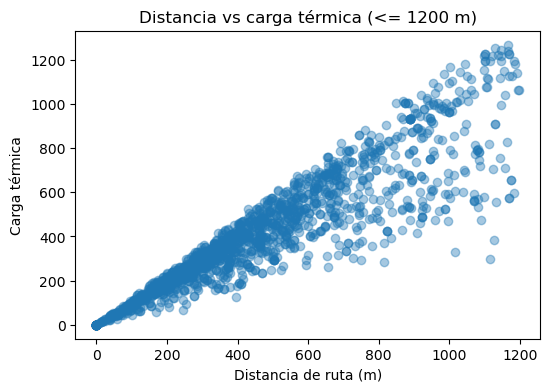

In [85]:
plt.figure(figsize=(6, 4))
plt.scatter(results_walk["route_length_m"], results_walk["heat_load"], alpha=0.4)
plt.xlabel("Distancia de ruta (m)")
plt.ylabel("Carga térmica")
plt.title(f"Distancia vs carga térmica (<= {UMBRAL_CAMINATA_M} m)")
plt.show()

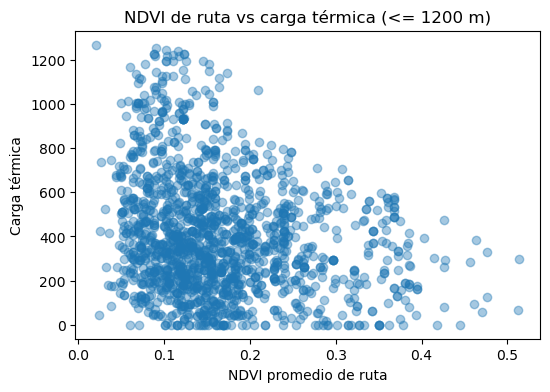

In [86]:
plt.figure(figsize=(6, 4))
plt.scatter(results_walk["ndvi_route"], results_walk["heat_load"], alpha=0.4)
plt.xlabel("NDVI promedio de ruta")
plt.ylabel("Carga térmica")
plt.title(f"NDVI de ruta vs carga térmica (<= {UMBRAL_CAMINATA_M} m)")
plt.show()

<Figure size 700x400 with 0 Axes>

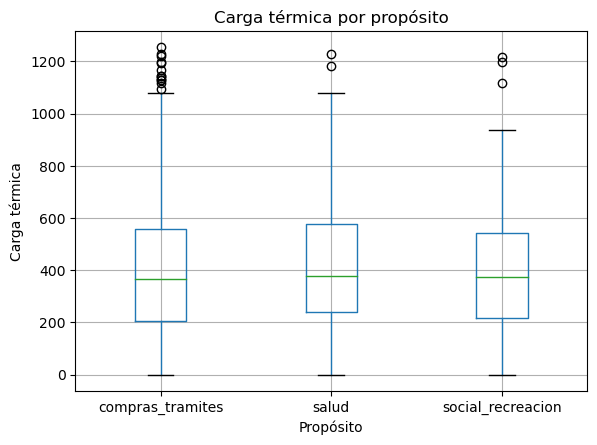

In [87]:
plt.figure(figsize=(7, 4))
results_walk.boxplot(column="heat_load", by="purpose_group")
plt.title("Carga térmica por propósito")
plt.suptitle("")
plt.xlabel("Propósito")
plt.ylabel("Carga térmica")
plt.show()

<Figure size 700x400 with 0 Axes>

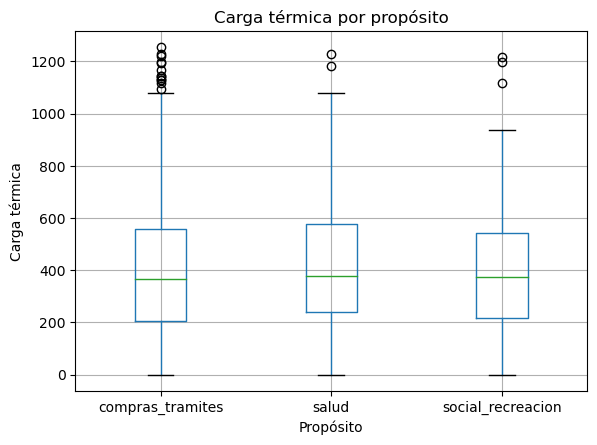

In [88]:
plt.figure(figsize=(7, 4))
results_walk.boxplot(column="heat_load", by="purpose_group")
plt.title("Carga térmica por propósito")
plt.suptitle("")
plt.xlabel("Propósito")
plt.ylabel("Carga térmica")
plt.show()

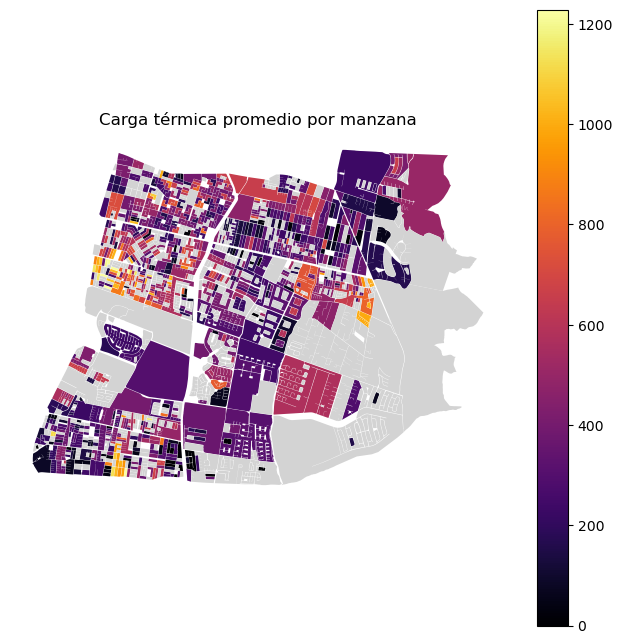

In [89]:
ax = manz_plot.plot(
    column="heat_mean",
    cmap="inferno",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey", "label": "Sin agentes"}
)
ax.set_title("Carga térmica promedio por manzana")
ax.set_axis_off()
plt.show()

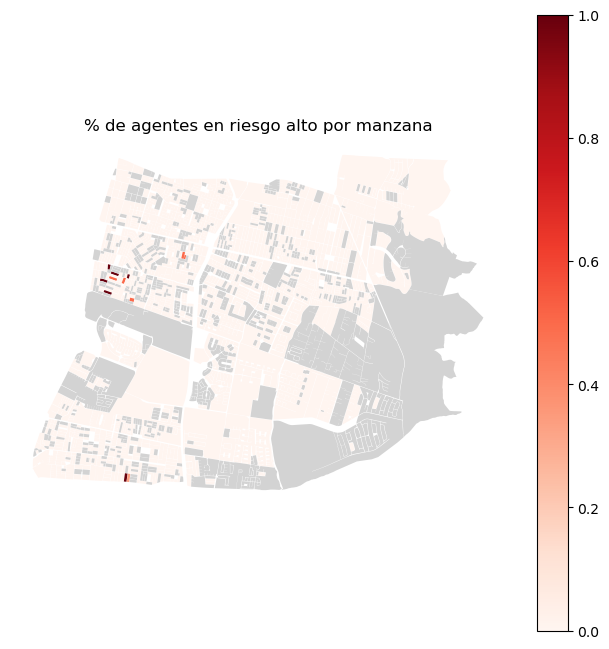

In [90]:
ax = manz_plot.plot(
    column="pct_risk_high",
    cmap="Reds",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey", "label": "Sin agentes"}
)
ax.set_title("% de agentes en riesgo alto por manzana")
ax.set_axis_off()
plt.show()

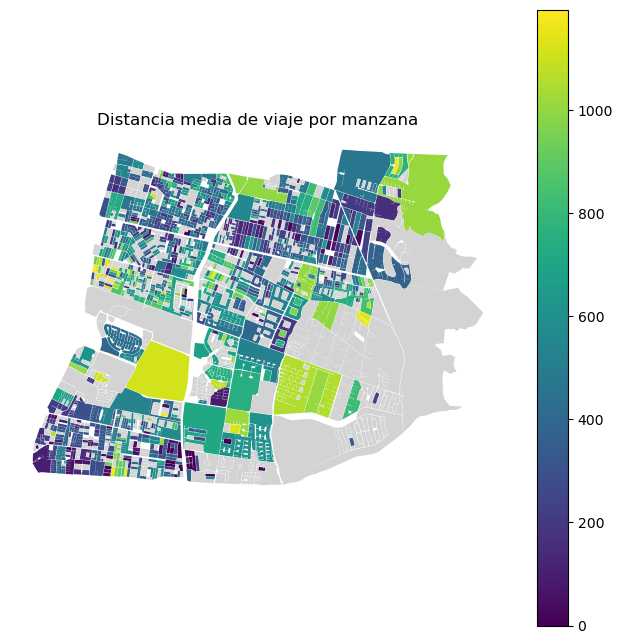

In [91]:
ax = manz_plot.plot(
    column="dist_mean_m",
    cmap="viridis",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey", "label": "Sin agentes"}
)
ax.set_title("Distancia media de viaje por manzana")
ax.set_axis_off()
plt.show()

In [92]:
print(results_walk["purpose_group"].value_counts())

purpose_group
compras_tramites     532
social_recreacion    119
salud                 61
Name: count, dtype: int64


In [93]:
print(
    results_walk.groupby("purpose_group")[["route_length_m", "heat_load", "ndvi_route"]]
    .mean()
)

                   route_length_m   heat_load  ndvi_route
purpose_group                                            
compras_tramites       457.185543  414.418883    0.158590
salud                  469.717295  436.693989    0.151400
social_recreacion      453.385042  404.553781    0.164341


In [94]:
print(
    results_walk.groupby(["purpose_group", "vuln_group"])["heat_load"]
    .mean()
)

purpose_group      vuln_group
compras_tramites   alta          463.426302
                   baja          321.884806
                   media         398.240688
salud              alta          492.584107
                   baja          350.439387
                   media         350.560280
social_recreacion  alta          402.899247
                   baja          278.233070
                   media         475.373741
Name: heat_load, dtype: float64
